**IDC402: Nonlinear Dynamics, Chaos and Complex Systems**

Phase space portraits

Integrating for mu = 4 (Regular)...
Integrating for mu = 3 (Chaotic)...
Plot saved as 'phase_space_placeholder.png'


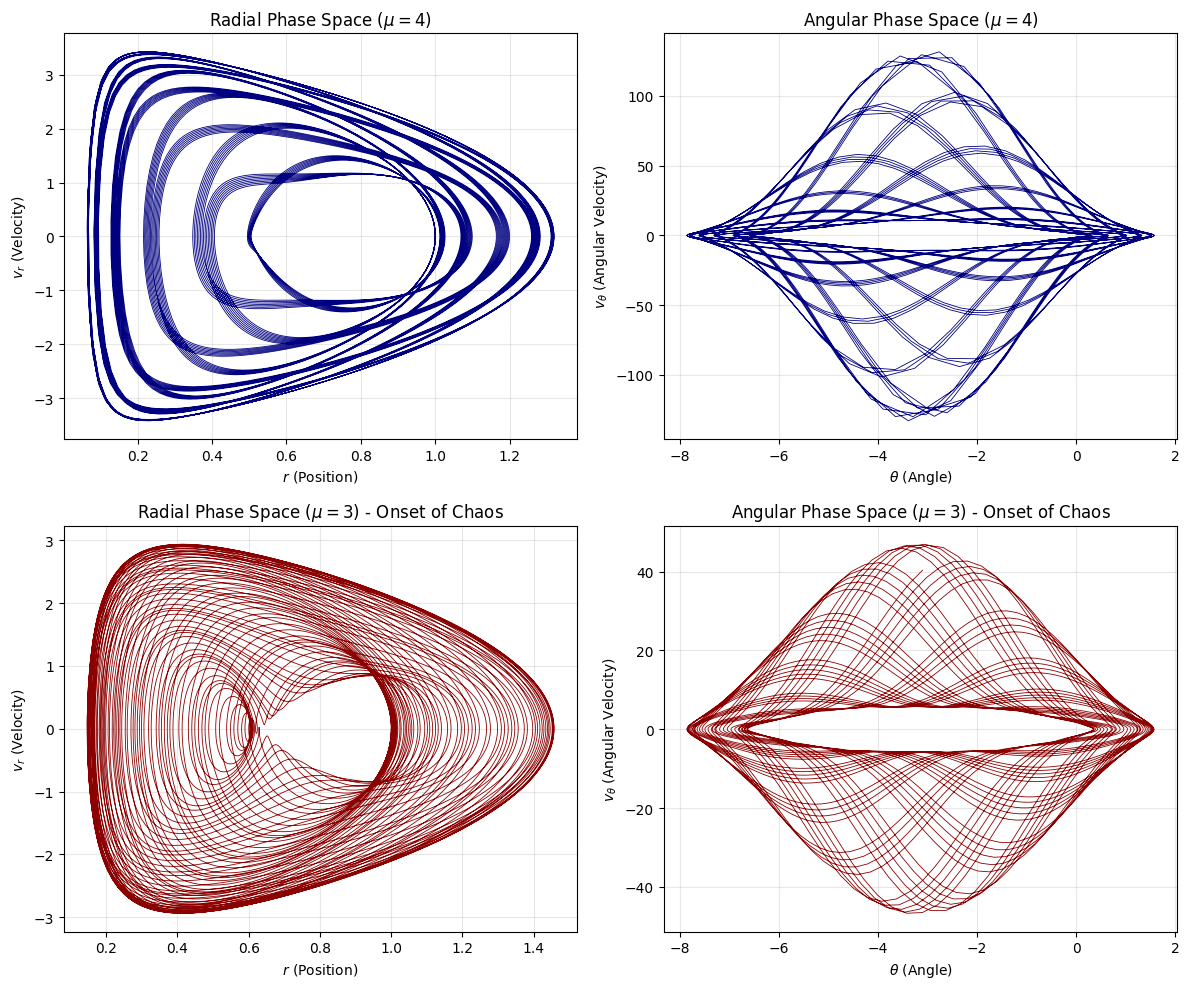

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- System Parameters ---
g = 9.81  # Acceleration due to gravity

# --- Equations of Motion ---
def sam_derivatives(t, y, mu):
    """
    Computes the derivatives for the Swinging Atwood's Machine.
    State vector y = [r, v_r, theta, v_theta]
    """
    r, vr, theta, vtheta = y

    # Mathematical safeguard: prevent the string from fully retracting (r=0 singularity)
    if r < 1e-5:
        r = 1e-5

    r_dot = vr
    vr_dot = (r * vtheta**2 - g * (mu - np.cos(theta))) / (mu + 1)

    theta_dot = vtheta
    vtheta_dot = -(2 * vr * vtheta + g * np.sin(theta)) / r

    return [r_dot, vr_dot, theta_dot, vtheta_dot]

# --- Simulation Setup ---
t_span = (0, 100)  # Simulate for 100 seconds
t_eval = np.linspace(t_span[0], t_span[1], 15000)  # High resolution for smooth curves

# Initial conditions: [r0, vr0, theta0, vtheta0]
# Starting the pendulum at a 90-degree angle from rest
y0 = [1.0, 0.0, np.pi/2, 0.0]

# --- Numerical Integration ---
# We use strict tolerances (rtol, atol) to ensure energy conservation
print("Integrating for mu = 4 (Regular)...")
sol_mu4 = solve_ivp(sam_derivatives, t_span, y0, args=(4,),
                    t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-9)

print("Integrating for mu = 3 (Chaotic)...")
sol_mu3 = solve_ivp(sam_derivatives, t_span, y0, args=(3,),
                    t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-9)

# --- Plotting ---
# Set up a 2x2 grid for the plots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plt.style.use('default')

# mu = 4: Radial Phase Space
axs[0, 0].plot(sol_mu4.y[0], sol_mu4.y[1], color='navy', linewidth=0.6)
axs[0, 0].set_title(r'Radial Phase Space ($\mu=4$)')
axs[0, 0].set_xlabel(r'$r$ (Position)')
axs[0, 0].set_ylabel(r'$v_r$ (Velocity)')
axs[0, 0].grid(True, alpha=0.3)

# mu = 4: Angular Phase Space
axs[0, 1].plot(sol_mu4.y[2], sol_mu4.y[3], color='navy', linewidth=0.6)
axs[0, 1].set_title(r'Angular Phase Space ($\mu=4$)')
axs[0, 1].set_xlabel(r'$\theta$ (Angle)')
axs[0, 1].set_ylabel(r'$v_\theta$ (Angular Velocity)')
axs[0, 1].grid(True, alpha=0.3)

# mu = 3: Radial Phase Space
axs[1, 0].plot(sol_mu3.y[0], sol_mu3.y[1], color='darkred', linewidth=0.6)
axs[1, 0].set_title(r'Radial Phase Space ($\mu=3$) - Onset of Chaos')
axs[1, 0].set_xlabel(r'$r$ (Position)')
axs[1, 0].set_ylabel(r'$v_r$ (Velocity)')
axs[1, 0].grid(True, alpha=0.3)

# mu = 3: Angular Phase Space
axs[1, 1].plot(sol_mu3.y[2], sol_mu3.y[3], color='darkred', linewidth=0.6)
axs[1, 1].set_title(r'Angular Phase Space ($\mu=3$) - Onset of Chaos')
axs[1, 1].set_xlabel(r'$\theta$ (Angle)')
axs[1, 1].set_ylabel(r'$v_\theta$ (Angular Velocity)')
axs[1, 1].grid(True, alpha=0.3)

# --- Output ---
plt.tight_layout()
# This saves the file exactly as named in your LaTeX document
plt.savefig('phase_space_placeholder.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'phase_space_placeholder.png'")
plt.show()

Poincare sections

Generating Poincaré section for mu = 4...
Generating Poincaré section for mu = 3...


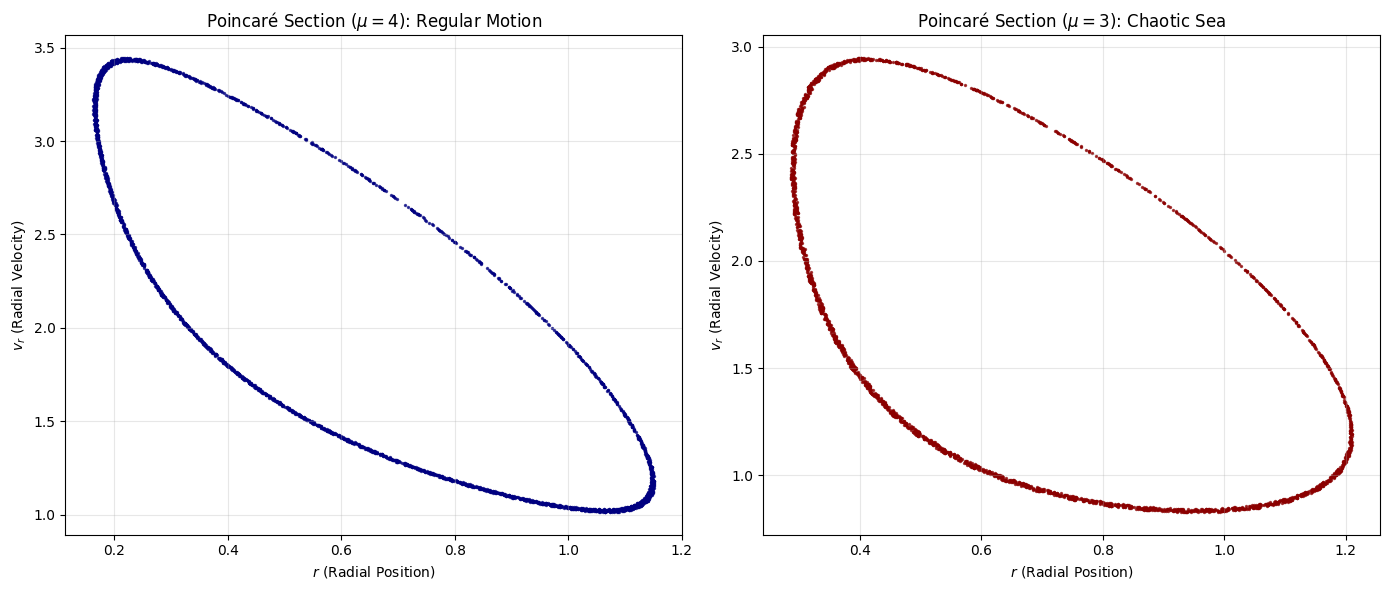

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- System Parameters ---
g = 9.81

# --- Equations of Motion ---
def sam_derivatives(t, y, mu):
    r, vr, theta, vtheta = y

    if r < 1e-5:
        r = 1e-5

    r_dot = vr
    vr_dot = (r * vtheta**2 - g * (mu - np.cos(theta))) / (mu + 1)
    theta_dot = vtheta
    vtheta_dot = -(2 * vr * vtheta + g * np.sin(theta)) / r

    return [r_dot, vr_dot, theta_dot, vtheta_dot]

# --- Event Detection (The Poincaré Slice) ---
def cross_theta_zero(t, y, mu):
    return y[2]

cross_theta_zero.direction = 1

# --- Optimized Simulation Setup ---
t_span = (0, 8000)  # Reduced from 15000 for faster execution
y0 = [1.0, 0.0, np.pi/2, 0.0]

print("Generating Poincaré section for mu = 4...")
sol_mu4 = solve_ivp(sam_derivatives, t_span, y0, args=(4,),
                    method='RK45', rtol=1e-6, atol=1e-6,  # Loosened tolerances
                    events=cross_theta_zero)

print("Generating Poincaré section for mu = 3...")
sol_mu3 = solve_ivp(sam_derivatives, t_span, y0, args=(3,),
                    method='RK45', rtol=1e-6, atol=1e-6,  # Loosened tolerances
                    events=cross_theta_zero)

# --- Extracting the Event Points ---
poincare_mu4_r = sol_mu4.y_events[0][:, 0]
poincare_mu4_vr = sol_mu4.y_events[0][:, 1]

poincare_mu3_r = sol_mu3.y_events[0][:, 0]
poincare_mu3_vr = sol_mu3.y_events[0][:, 1]

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
plt.style.use('default')

# mu = 4: Regular Motion
axs[0].scatter(poincare_mu4_r, poincare_mu4_vr, s=2, color='navy', alpha=0.7)
axs[0].set_title(r'Poincaré Section ($\mu=4$): Regular Motion')
axs[0].set_xlabel(r'$r$ (Radial Position)')
axs[0].set_ylabel(r'$v_r$ (Radial Velocity)')
axs[0].grid(True, alpha=0.3)

# mu = 3: Chaotic Sea
axs[1].scatter(poincare_mu3_r, poincare_mu3_vr, s=2, color='darkred', alpha=0.7)
axs[1].set_title(r'Poincaré Section ($\mu=3$): Chaotic Sea')
axs[1].set_xlabel(r'$r$ (Radial Position)')
axs[1].set_ylabel(r'$v_r$ (Radial Velocity)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Convergence of the maximal Lyapunov exponent

Calculating Lyapunov Exponent for mu = 4...
Calculating Lyapunov Exponent for mu = 3...


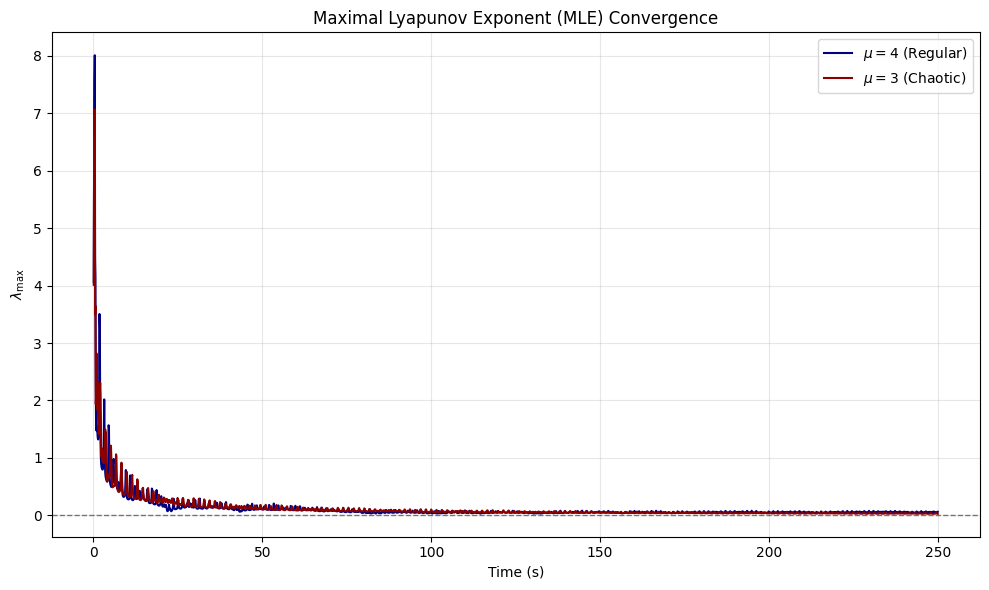

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
g = 9.81

# --- Equations of Motion ---
def sam_derivatives(y, mu):
    r, vr, theta, vtheta = y

    if r < 1e-5:
        r = 1e-5

    r_dot = vr
    vr_dot = (r * vtheta**2 - g * (mu - np.cos(theta))) / (mu + 1)
    theta_dot = vtheta
    vtheta_dot = -(2 * vr * vtheta + g * np.sin(theta)) / r

    return np.array([r_dot, vr_dot, theta_dot, vtheta_dot])

# --- Custom RK4 Integrator ---
def rk4_step(y, h, mu):
    k1 = sam_derivatives(y, mu)
    k2 = sam_derivatives(y + 0.5 * h * k1, mu)
    k3 = sam_derivatives(y + 0.5 * h * k2, mu)
    k4 = sam_derivatives(y + h * k3, mu)
    return y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# --- Benettin's Algorithm for Lyapunov Exponents ---
def calculate_lyapunov(mu, t_max, h, tau_steps):
    y = np.array([1.0, 0.0, np.pi/2, 0.0]) # Reference trajectory

    # Perturbed trajectory (separated by a microscopic distance d0)
    d0 = 1e-8
    y_pert = y + np.array([d0, 0.0, 0.0, 0.0])

    time = 0.0
    times = []
    lyap_vals = []
    sum_log = 0.0

    n_renorms = int(t_max / (h * tau_steps))

    for _ in range(n_renorms):
        # Evolve both trajectories for 'tau_steps'
        for _ in range(tau_steps):
            y = rk4_step(y, h, mu)
            y_pert = rk4_step(y_pert, h, mu)
            time += h

        # Measure divergence
        delta = y_pert - y
        d = np.linalg.norm(delta)

        # Accumulate the log of the distance ratio
        sum_log += np.log(d / d0)

        # Record the current estimate of the Maximal Lyapunov Exponent
        times.append(time)
        lyap_vals.append(sum_log / time)

        # Renormalize the perturbed trajectory back to distance d0 along the same direction
        y_pert = y + (delta / d) * d0

    return times, lyap_vals

# --- Optimized Simulation Setup ---
t_max = 250       # Reduced from 500 to cut execution time in half
h = 0.01          # Integration time step
tau_steps = 10    # Renormalize every 10 steps (every 0.1 seconds)

print("Calculating Lyapunov Exponent for mu = 4...")
times_mu4, lyap_mu4 = calculate_lyapunov(4.0, t_max, h, tau_steps)

print("Calculating Lyapunov Exponent for mu = 3...")
times_mu3, lyap_mu3 = calculate_lyapunov(3.0, t_max, h, tau_steps)

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.style.use('default')

# Plot both lines
plt.plot(times_mu4, lyap_mu4, color='navy', label=r'$\mu=4$ (Regular)')
plt.plot(times_mu3, lyap_mu3, color='darkred', label=r'$\mu=3$ (Chaotic)')

# Add a dashed line at zero to visually separate chaotic from regular regimes
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Maximal Lyapunov Exponent (MLE) Convergence')
plt.xlabel('Time (s)')
plt.ylabel(r'$\lambda_{\text{max}}$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# --- Output ---
plt.tight_layout()
plt.show() # Displays directly without saving to disk